## Problem Statement
Create an algorithm capable of correctly classifying a mushroom as edible or poisonous.

We'll start by importing the necessary libraries.

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Load our dataset.

In [ ]:
#loading our dataset
mushroom_df = pd.read_csv('./data/mushroom_data.csv', sep=';')

#display the first 5 rows
mushroom_df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [5]:
mushroom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

In [7]:
ex_df = mushroom_df[['class', 'cap-diameter', 'stem-height', 'stem-width']]

ex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   class         61069 non-null  object 
 1   cap-diameter  61069 non-null  float64
 2   stem-height   61069 non-null  float64
 3   stem-width    61069 non-null  float64
dtypes: float64(3), object(1)
memory usage: 1.9+ MB


In [10]:
test_df = pd.get_dummies(ex_df)

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cap-diameter  61069 non-null  float64
 1   stem-height   61069 non-null  float64
 2   stem-width    61069 non-null  float64
 3   class_e       61069 non-null  bool   
 4   class_p       61069 non-null  bool   
dtypes: bool(2), float64(3)
memory usage: 1.5 MB


In [11]:
ex_df.head()

,class,cap-diameter,stem-height,stem-width
0,p,15.26,16.95,17.09
1,p,16.60,17.99,18.19
2,p,14.07,17.80,17.74
3,p,14.17,15.77,15.98
4,p,14.64,16.53,17.20


In [8]:
test_df = pd.get_dummies(ex_df, drop_first=True)

test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cap-diameter  61069 non-null  float64
 1   stem-height   61069 non-null  float64
 2   stem-width    61069 non-null  float64
 3   class_p       61069 non-null  bool   
dtypes: bool(1), float64(3)
memory usage: 1.5 MB


In [9]:
test_df.head()

,cap-diameter,stem-height,stem-width,class_p
0,15.26,16.95,17.09,True
1,16.60,17.99,18.19,True
2,14.07,17.80,17.74,True
3,14.17,15.77,15.98,True
4,14.64,16.53,17.20,True


In [13]:
test_df.describe()

,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,6.733854,6.581538,12.149410
std,5.264845,3.370017,10.035955
min,0.380000,0.000000,0.000000
25%,3.480000,4.640000,5.210000
50%,5.860000,5.950000,10.190000
75%,8.540000,7.740000,16.570000
max,62.340000,33.920000,103.910000


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression



#split our dataset
X = test_df.drop('class_p', axis=1)
y = pd.DataFrame(test_df['class_p'])
# y = test_df[['class_p']]


X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state = 254)

In [29]:
type(y)

pandas.core.frame.DataFrame

In [25]:
#instantiate the model
log_r = LogisticRegression()

#train the model
log_r.fit(X_train, y_train)

c:\Users\marwa\miniconda3\envs\xBase\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [26]:
#predict 
y_preds = log_r.predict(X_test)

#y_test

## Classification Metrics of Success
1. `Accuracy`
2. `Precision`
3. `Recall`
4. `F1_score`

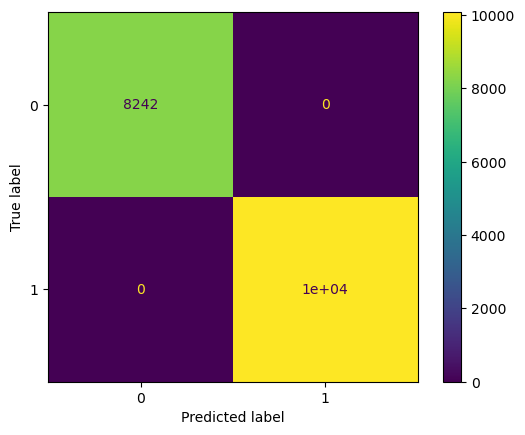

In [27]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_preds)

display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.show()

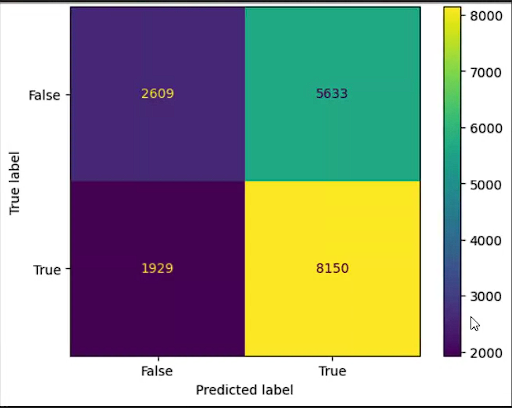